# Monthly Storage Sizing — Scenarios S2 and S5

**Purpose**  
Extends the flat-winter storage sizing in `analysis.ipynb` by:
1. Using **month-specific peak demand** from the 1-in-20 demand model
   (file `data/r_max_den_2025-2026.csv`, units: MWh/d).
2. Computing **month-specific import percentiles** from the post-March 2022
   ENTSOG data so that the import baseline reflects seasonal variation.
3. Applying the **S2 (P20 imports)** and **S5 (P70 imports)** scenarios
   to arrive at a month-by-month storage gap and cumulative storage
   requirement.

**Storage formula (per month)**
```
daily_gap_m  = max(0, peak_demand_m − reliable_import_m)
storage_m    = daily_gap_m × days_in_month_m
```
where `reliable_import_m` is the k-th percentile of daily imports observed
in calendar month `m` across all post-cutoff winters.

---
## 0. Setup

In [1]:
%cd ..

/Users/martinsik/Coding/bsd_revamp


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import bsd.data as bdata
import bsd.capacity as bcap
import bsd.jvs as jvs

jvs.apply_style(theme="light", context="notebook")
_sc = jvs.PALETTES["scenarios"]

%matplotlib inline

DATA_FILE      = bdata.DATA_PATH_IMPORTS
PEAK_FILE      = bdata.DATA_PATH_DEMAND_PEAK
CUTOFF         = bdata.DEFAULT_CUTOFF   # 2022-03-01

# S2=index 1 (Stressed), S5=index 4 (Favourable)
SCENARIOS = {
    "S2": {"label": "S2 — Stressed",   "percentile": 20, "color": _sc[1]},
    "S5": {"label": "S5 — Favourable", "percentile": 70, "color": _sc[4]},
}

MONTH_ORDER = [10, 11, 12, 1, 2, 3]   # Oct … Mar
MONTH_NAMES = {10: "Oct", 11: "Nov", 12: "Dec", 1: "Jan", 2: "Feb", 3: "Mar"}
DAYS_IN_MONTH = {10: 31, 11: 30, 12: 31, 1: 31, 2: 28, 3: 31}  # non-leap average for Feb

---
## 1. Monthly peak demand

In [3]:
peak_raw = pd.read_csv(PEAK_FILE)
peak_raw.columns = peak_raw.columns.str.strip()

# Map month names to numbers and convert MWh/d → GWh/d
MONTH_NUM = {
    "october": 10, "november": 11, "december": 12,
    "january": 1,  "february": 2,  "march": 3,
}
peak_raw["month_num"] = peak_raw["month"].str.lower().map(MONTH_NUM)
peak_raw["peak_GWh_d"] = peak_raw["value [mhw]"] / 1000

peak = (
    peak_raw[["month_num", "peak_GWh_d"]]
    .set_index("month_num")
    .reindex(MONTH_ORDER)
)
peak["month_name"] = peak.index.map(MONTH_NAMES)
print(peak[["month_name", "peak_GWh_d"]])

          month_name  peak_GWh_d
month_num                       
10               Oct     163.239
11               Nov     244.370
12               Dec     325.367
1                Jan     367.774
2                Feb     326.700
3                Mar     244.642


---
## 2. Load import data and compute month-specific percentiles

In [4]:
daily = bdata.load_daily_imports(DATA_FILE, cutoff=CUTOFF)
winter = daily[daily["month"].isin(MONTH_ORDER)].copy()

# Month-specific percentiles for each scenario
records = []
for m in MONTH_ORDER:
    m_days = winter[winter["month"] == m]["GWh_d"]
    row = {"month_num": m, "month_name": MONTH_NAMES[m], "n_obs": len(m_days)}
    for key, sc in SCENARIOS.items():
        row[f"import_p{sc['percentile']}_{key}"] = m_days.quantile(sc["percentile"] / 100)
    records.append(row)

monthly_imports = pd.DataFrame(records).set_index("month_num")
monthly_imports

,month_name,n_obs,import_p20_S2,import_p70_S5
month_num,,,,
10,Oct,124,212.502340,356.896002
11,Nov,120,159.832741,341.951263
12,Dec,124,141.577177,340.882302
1,Jan,124,134.953986,272.035111
2,Feb,113,148.888172,243.888215
3,Mar,155,195.835774,350.435526


---
## 3. Monthly storage gap — S2 and S5

In [5]:
results = monthly_imports.join(peak[["peak_GWh_d"]])
results["days"] = pd.Series(DAYS_IN_MONTH)

for key, sc in SCENARIOS.items():
    imp_col = f"import_p{sc['percentile']}_{key}"
    results[f"gap_{key}_GWh_d"]  = (results["peak_GWh_d"] - results[imp_col]).clip(lower=0).round(1)
    results[f"storage_{key}_GWh"] = (results[f"gap_{key}_GWh_d"] * results["days"]).round(0)
    results[f"storage_{key}_TWh"] = (results[f"storage_{key}_GWh"] / 1000).round(2)

display_cols = (
    ["month_name", "peak_GWh_d", "n_obs"]
    + [c for key in SCENARIOS for c in [
        f"import_p{SCENARIOS[key]['percentile']}_{key}",
        f"gap_{key}_GWh_d",
        f"storage_{key}_TWh",
    ]]
)
results[display_cols].round(2)

,month_name,peak_GWh_d,n_obs,import_p20_S2,gap_S2_GWh_d,storage_S2_TWh,import_p70_S5,gap_S5_GWh_d,storage_S5_TWh
month_num,,,,,,,,,
10,Oct,163.24,124,212.50,0.0,0.00,356.90,0.0,0.00
11,Nov,244.37,120,159.83,84.5,2.54,341.95,0.0,0.00
12,Dec,325.37,124,141.58,183.8,5.70,340.88,0.0,0.00
1,Jan,367.77,124,134.95,232.8,7.22,272.04,95.7,2.97
2,Feb,326.70,113,148.89,177.8,4.98,243.89,82.8,2.32
3,Mar,244.64,155,195.84,48.8,1.51,350.44,0.0,0.00


In [6]:
# Seasonal totals
for key in SCENARIOS:
    total = results[f"storage_{key}_GWh"].sum()
    print(f"{SCENARIOS[key]['label']:30s}  total seasonal storage = {total:,.0f} GWh  ({total/1000:.2f} TWh)")

S2 — Stressed                   total seasonal storage = 21,941 GWh  (21.94 TWh)
S5 — Favourable                 total seasonal storage = 5,285 GWh  (5.29 TWh)


---
## 4. Charts

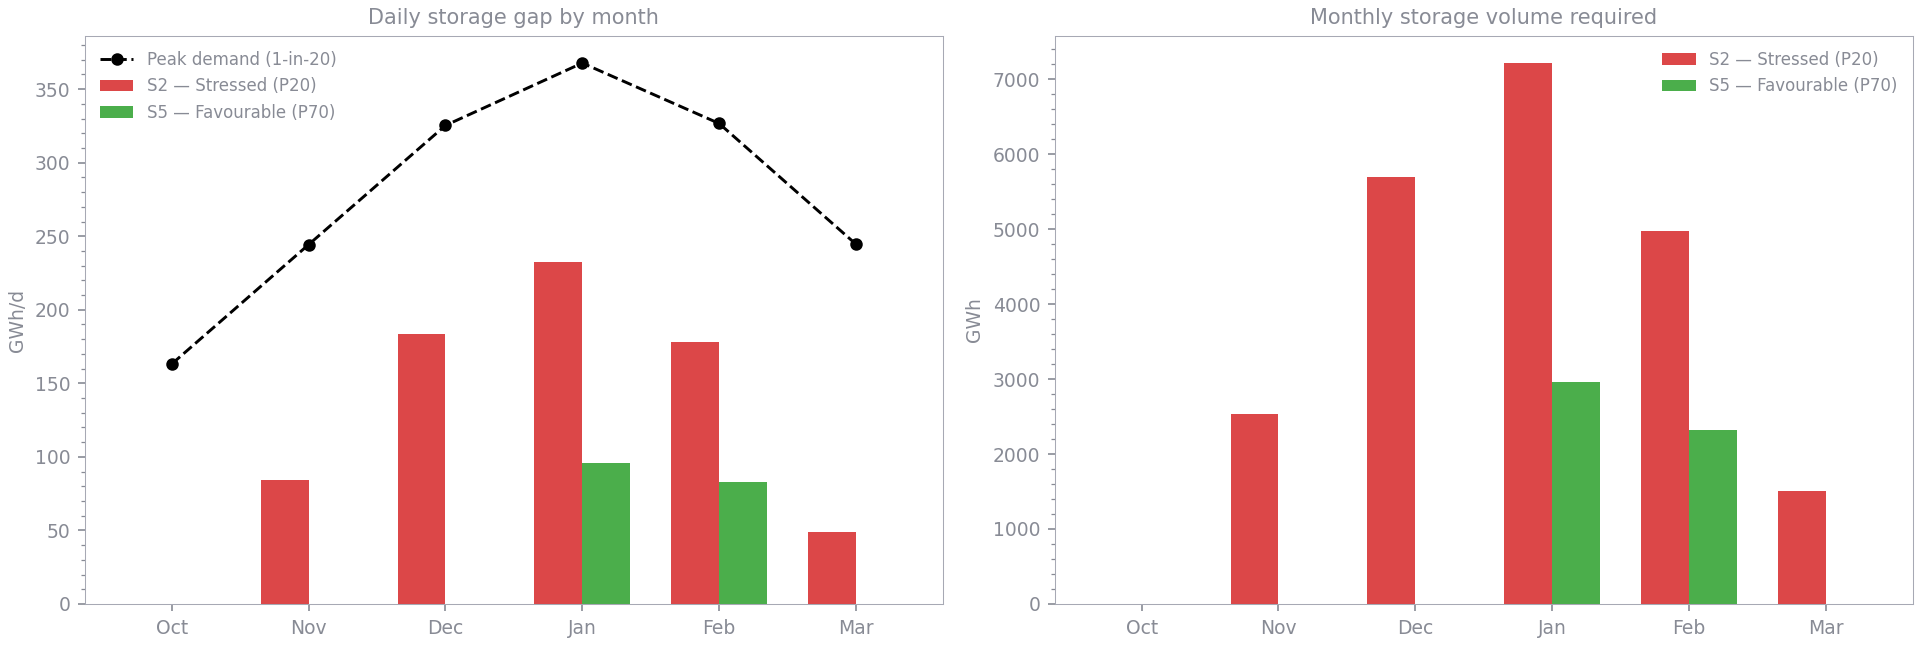

In [7]:
month_labels = results["month_name"].values
x = np.arange(len(month_labels))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ── left: daily gap (GWh/d) ──────────────────────────────────────────────
ax = axes[0]
ax.bar(x - width/2, results["gap_S2_GWh_d"], width, label="S2 — Stressed (P20)",
       color=SCENARIOS["S2"]["color"], alpha=0.85)
ax.bar(x + width/2, results["gap_S5_GWh_d"], width, label="S5 — Favourable (P70)",
       color=SCENARIOS["S5"]["color"], alpha=0.85)
ax.plot(x, results["peak_GWh_d"], "k--o", ms=5, lw=1.4, label="Peak demand (1-in-20)")
ax.set_xticks(x); ax.set_xticklabels(month_labels)
ax.set_ylabel("GWh/d")
ax.set_title("Daily storage gap by month")
ax.legend(fontsize=8)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())

# ── right: monthly storage volume (GWh) ─────────────────────────────────
ax = axes[1]
ax.bar(x - width/2, results["storage_S2_GWh"], width, label="S2 — Stressed (P20)",
       color=SCENARIOS["S2"]["color"], alpha=0.85)
ax.bar(x + width/2, results["storage_S5_GWh"], width, label="S5 — Favourable (P70)",
       color=SCENARIOS["S5"]["color"], alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(month_labels)
ax.set_ylabel("GWh")
ax.set_title("Monthly storage volume required")
ax.legend(fontsize=8)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())

fig.tight_layout()
fig.savefig("figs/storage_monthly_s2_s5.png", bbox_inches="tight")
fig;

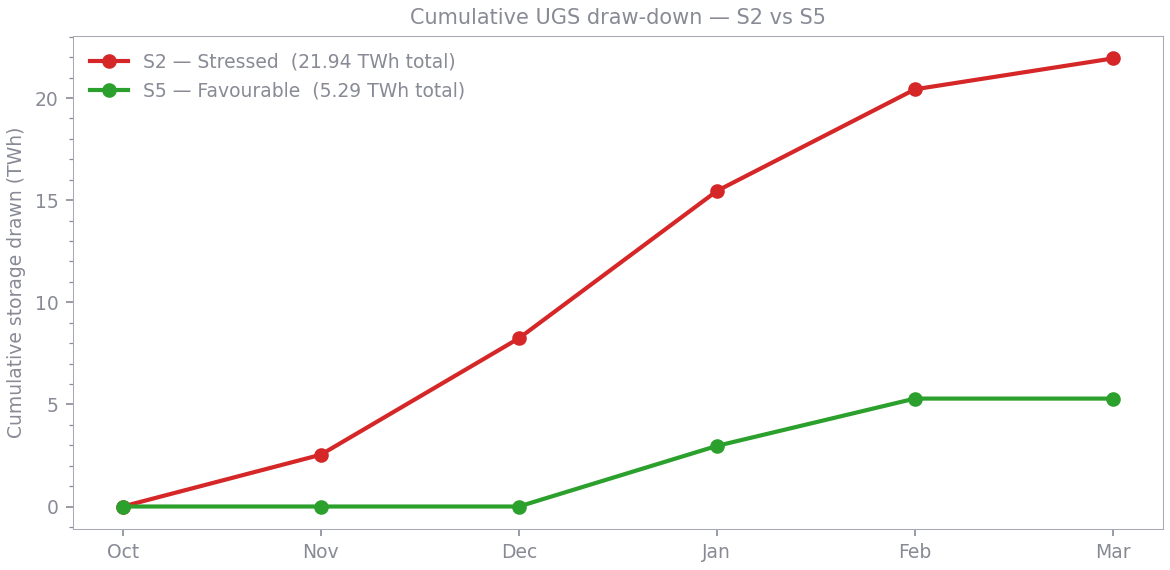

In [8]:
# Cumulative storage draw-down across the season (Oct → Mar)
fig, ax = plt.subplots(figsize=(8, 4))

for key in ["S2", "S5"]:
    cumul = results[f"storage_{key}_GWh"].cumsum()
    ax.plot(x, cumul / 1000, "o-", color=SCENARIOS[key]["color"], lw=2, ms=6,
            label=f"{SCENARIOS[key]['label']}  ({cumul.iloc[-1]/1000:.2f} TWh total)")

ax.set_xticks(x); ax.set_xticklabels(month_labels)
ax.set_ylabel("Cumulative storage drawn (TWh)")
ax.set_title("Cumulative UGS draw-down — S2 vs S5")
ax.legend()
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator())
fig.tight_layout()
fig.savefig("figs/storage_monthly_cumul.png", bbox_inches="tight")
fig;

---
## 5. Notes

- **Monthly vs. 30-day rolling average**: `analysis.ipynb` uses the P-k of
  the 30-day rolling-average import as the 'sustained reliable import'.
  Here we use the P-k of *single-day* imports within each calendar month.
  The two are not directly comparable: the rolling-average approach smooths
  out intra-month variance, typically producing a slightly higher percentile
  value (less conservative). The month-by-month approach is more granular
  and allows peak demand to vary by month.

- **February days**: February is treated as 28 days (non-leap average).
  Adjust `DAYS_IN_MONTH` if using a leap year.

- **Sample size**: October and March each have ~4 post-cutoff observations
  per year, giving ~12–16 data points. Percentile estimates for those months
  carry more uncertainty than the core winter months (Nov–Feb).